In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make src/ importable from a notebook in notebooks/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import src.data_loader
import src.features
import src.train

from src.data_loader import generate_mock_dam_prices
from src.features import (
    build_supervised_dataset,
    make_calendar_features,
    make_forecast_time_features,
    make_target_relative_lags,
)
from src.train import train_per_horizon_models, predict_next_day

print("Imports OK.")

Imports OK.


In [2]:
prices = generate_mock_dam_prices(
    start=pd.Timestamp("2024-01-01", tz="Europe/Athens"),
    end=pd.Timestamp("2024-07-01", tz="Europe/Athens"),
)

print(f"Rows: {len(prices)}")
print(f"From: {prices.index.min()}")
print(f"To:   {prices.index.max()}")
print(f"Mean: {prices.mean():.1f} EUR/MWh,  Std: {prices.std():.1f}")

Rows: 4367
From: 2024-01-01 00:00:00+02:00
To:   2024-06-30 23:00:00+03:00
Mean: 95.6 EUR/MWh,  Std: 27.5


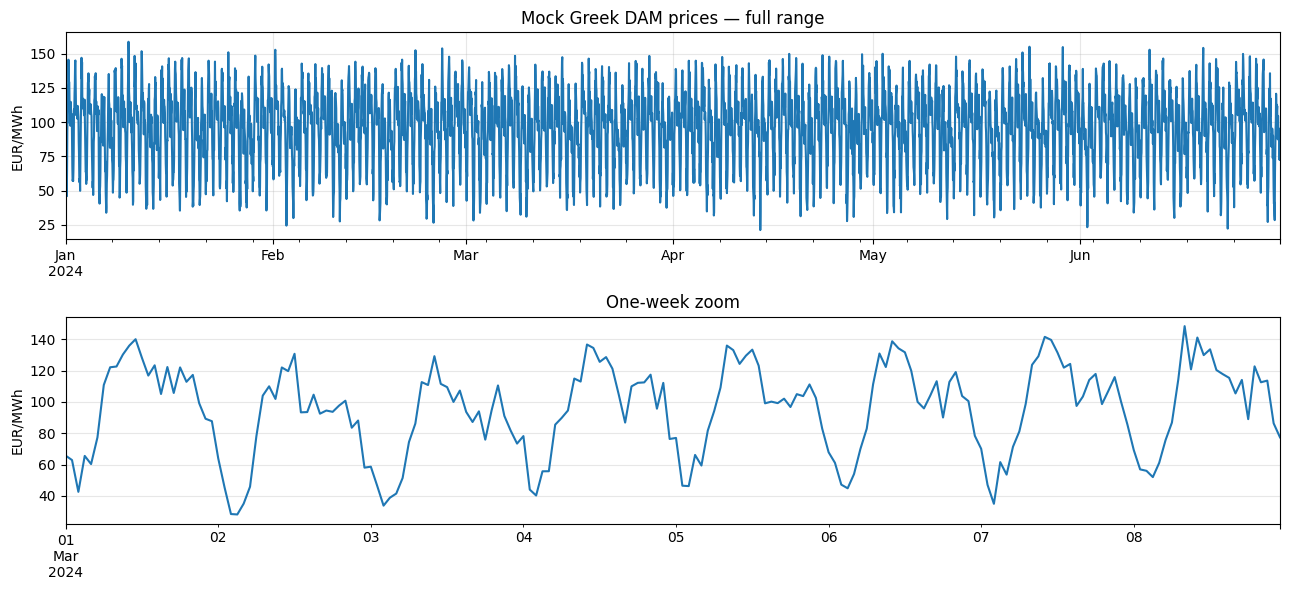

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
prices.plot(ax=axes[0], title="Mock Greek DAM prices — full range")
axes[0].set_ylabel("EUR/MWh")
axes[0].grid(alpha=0.3)

prices.loc["2024-03-01":"2024-03-08"].plot(ax=axes[1], title="One-week zoom")
axes[1].set_ylabel("EUR/MWh")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
X, y, meta = build_supervised_dataset(
    prices,
    gate_closure_hour=12,
    horizons=tuple(range(0, 24)),    # <-- changed from range(12, 36)
    same_hour_lag_days=(1, 2, 7),
    context_window=1,
)

In [11]:
ft_cols = [c for c in X.columns if c.startswith("ft_")]
tr_cols = [c for c in X.columns if c.startswith("tr_")]
target_cols = [c for c in X.columns if c.startswith("target_")]
other = [c for c in X.columns if c not in ft_cols + tr_cols + target_cols]

print(f"Forecast-time features ({len(ft_cols)}):")
for c in ft_cols: print(f"  {c}")
print(f"\nTarget-relative lag features ({len(tr_cols)}):")
for c in tr_cols: print(f"  {c}")
print(f"\nCalendar features ({len(target_cols)}):")
for c in target_cols: print(f"  {c}")
print(f"\nOther ({len(other)}): {other}")

Forecast-time features (12):
  ft_price_minus_0h
  ft_price_minus_1h
  ft_price_minus_2h
  ft_price_minus_3h
  ft_mean_24h
  ft_std_24h
  ft_max_24h
  ft_min_24h
  ft_mean_168h
  ft_std_168h
  ft_max_168h
  ft_min_168h

Target-relative lag features (9):
  tr_lag_d1_k-1
  tr_lag_d1_k+0
  tr_lag_d1_k+1
  tr_lag_d2_k-1
  tr_lag_d2_k+0
  tr_lag_d2_k+1
  tr_lag_d7_k-1
  tr_lag_d7_k+0
  tr_lag_d7_k+1

Calendar features (9):
  target_hour
  target_dow
  target_month
  target_is_weekend
  target_is_holiday
  target_hour_sin
  target_hour_cos
  target_dow_sin
  target_dow_cos

Other (1): ['horizon']


In [12]:
print("NaN pattern in tr_* features by horizon (after warm-up).\n")
print(f"{'horizon':>7} | {'NaN tr_* columns':<55} | n_NaN")
print("-" * 80)

for h in sorted(meta["horizon"].unique()):
    mask = (meta["horizon"] == h)
    rows_for_h = X[mask].reset_index(drop=True)
    sample = rows_for_h.iloc[10]
    nan_cols = [c for c in tr_cols if pd.isna(sample[c])]
    label = ", ".join(c.replace("tr_lag_", "") for c in nan_cols) or "(none)"
    print(f"{h:>7} | {label:<55} | {len(nan_cols)}")

NaN pattern in tr_* features by horizon (after warm-up).

horizon | NaN tr_* columns                                        | n_NaN
--------------------------------------------------------------------------------
      0 | (none)                                                  | 0
      1 | (none)                                                  | 0
      2 | (none)                                                  | 0
      3 | (none)                                                  | 0
      4 | (none)                                                  | 0
      5 | (none)                                                  | 0
      6 | (none)                                                  | 0
      7 | (none)                                                  | 0
      8 | (none)                                                  | 0
      9 | (none)                                                  | 0
     10 | (none)                                                  | 0
     11 | (none) 

In [14]:
target_day = meta["forecast_time"].iloc[len(meta) // 2]  # middle of dataset
mask = meta["forecast_time"] == target_day
day_meta = meta[mask].reset_index(drop=True)
day_X = X[mask].reset_index(drop=True)
day_y = y[mask].reset_index(drop=True)

h_to_show = 20
row_idx = day_meta[day_meta["horizon"] == h_to_show].index[0]

print(f"Forecast time: {day_meta.loc[row_idx, 'forecast_time']}")
print(f"Target time:   {day_meta.loc[row_idx, 'target_time']}")
print(f"Horizon:       {h_to_show}")
print(f"Target value:  {day_y.iloc[row_idx]:.2f} EUR/MWh\n")

for col in day_X.columns:
    val = day_X.loc[row_idx, col]
    val_str = f"{val:.2f}" if pd.notna(val) else "NaN"
    print(f"  {col:25s} = {val_str}")

Forecast time: 2024-01-01 12:00:00+02:00
Target time:   2024-01-02 20:00:00+02:00
Horizon:       20
Target value:  110.49 EUR/MWh

  ft_price_minus_0h         = 129.51
  ft_price_minus_1h         = 142.20
  ft_price_minus_2h         = 145.57
  ft_price_minus_3h         = 128.18
  ft_mean_24h               = 94.46
  ft_std_24h                = 36.71
  ft_max_24h                = 145.57
  ft_min_24h                = 45.86
  ft_mean_168h              = 94.46
  ft_std_168h               = 36.71
  ft_max_168h               = 145.57
  ft_min_168h               = 45.86
  tr_lag_d1_k-1             = NaN
  tr_lag_d1_k+0             = NaN
  tr_lag_d1_k+1             = NaN
  tr_lag_d2_k-1             = NaN
  tr_lag_d2_k+0             = NaN
  tr_lag_d2_k+1             = NaN
  tr_lag_d7_k-1             = NaN
  tr_lag_d7_k+0             = NaN
  tr_lag_d7_k+1             = NaN
  target_hour               = 20.00
  target_dow                = 1.00
  target_month              = 1.00
  target_is_weekend

In [15]:
print("Are ft_* features identical across all 24 horizons of one forecast day?")
print("(Each should report '1 unique value')\n")
for c in ft_cols:
    print(f"  {c:25s}: {day_X[c].nunique()} unique values")

Are ft_* features identical across all 24 horizons of one forecast day?
(Each should report '1 unique value')

  ft_price_minus_0h        : 1 unique values
  ft_price_minus_1h        : 1 unique values
  ft_price_minus_2h        : 1 unique values
  ft_price_minus_3h        : 1 unique values
  ft_mean_24h              : 1 unique values
  ft_std_24h               : 1 unique values
  ft_max_24h               : 1 unique values
  ft_min_24h               : 1 unique values
  ft_mean_168h             : 1 unique values
  ft_std_168h              : 1 unique values
  ft_max_168h              : 1 unique values
  ft_min_168h              : 1 unique values


In [16]:
target_cols

['target_hour',
 'target_dow',
 'target_month',
 'target_is_weekend',
 'target_is_holiday',
 'target_hour_sin',
 'target_hour_cos',
 'target_dow_sin',
 'target_dow_cos']

In [17]:
print("Do target_* features differ across horizons of one day?")
print("(target_hour should have ~24 unique values)\n")
for c in target_cols:
    print(f"  {c:25s}: {day_X[c].nunique()} unique values")

Do target_* features differ across horizons of one day?
(target_hour should have ~24 unique values)

  target_hour              : 24 unique values
  target_dow               : 1 unique values
  target_month             : 1 unique values
  target_is_weekend        : 1 unique values
  target_is_holiday        : 1 unique values
  target_hour_sin          : 21 unique values
  target_hour_cos          : 22 unique values
  target_dow_sin           : 1 unique values
  target_dow_cos           : 1 unique values


In [18]:
result = train_per_horizon_models(
    prices,
    gate_closure_hour=12,
    horizons=tuple(range(0, 24)),
    same_hour_lag_days=(1, 2, 7),
    context_window=1,
    test_days=14,
)

print(f"Trained {len(result.models)} per-horizon models.")
print(f"Overall test MAE:  {result.overall_test_mae:.2f} EUR/MWh")
print(f"Overall test RMSE: {result.overall_test_rmse:.2f} EUR/MWh")

Trained 24 per-horizon models.
Overall test MAE:  6.89 EUR/MWh
Overall test RMSE: 8.61 EUR/MWh


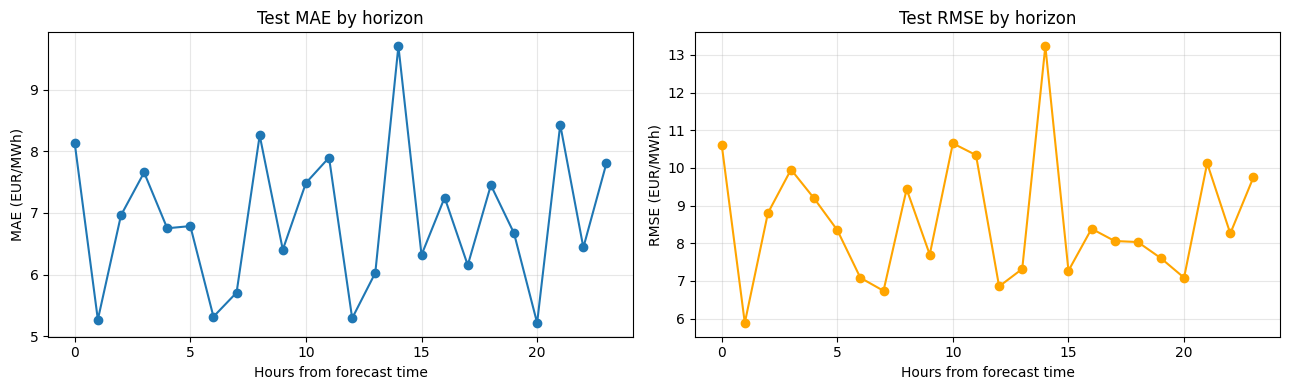

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

result.metrics_per_horizon.plot(
    x="horizon", y="mae", marker="o", ax=axes[0], legend=False
)
axes[0].set_title("Test MAE by horizon")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].set_xlabel("Hours from forecast time")
axes[0].grid(alpha=0.3)

result.metrics_per_horizon.plot(
    x="horizon", y="rmse", marker="o", color="orange", ax=axes[1], legend=False
)
axes[1].set_title("Test RMSE by horizon")
axes[1].set_ylabel("RMSE (EUR/MWh)")
axes[1].set_xlabel("Hours from forecast time")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

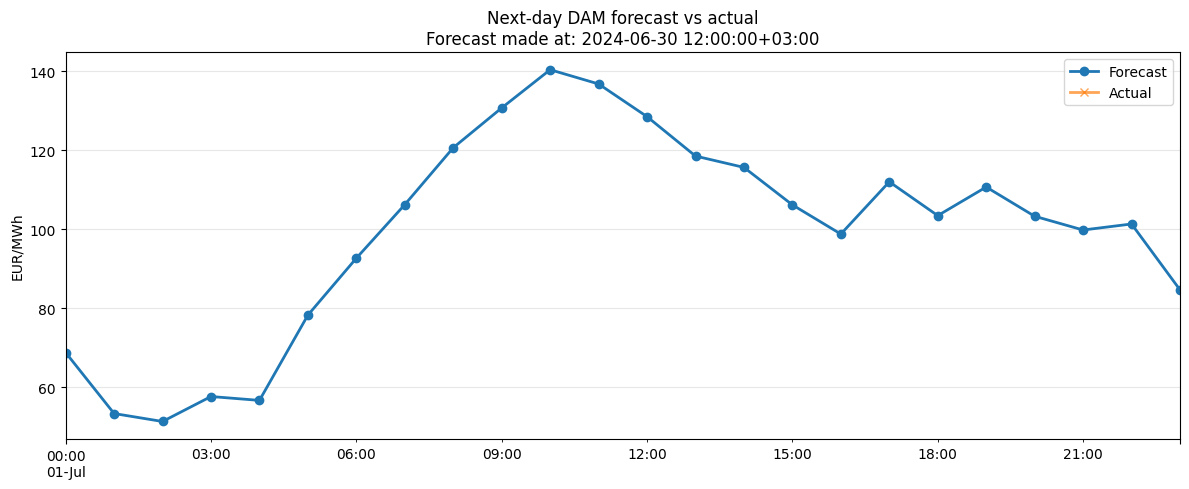

This day's MAE: nan EUR/MWh


In [20]:
forecast = predict_next_day(result, prices)
actuals = prices.reindex(forecast.index)

fig, ax = plt.subplots(figsize=(12, 5))
forecast.plot(ax=ax, marker="o", label="Forecast", linewidth=2)
actuals.plot(ax=ax, marker="x", label="Actual", linewidth=2, alpha=0.7)
ax.set_title(f"Next-day DAM forecast vs actual\nForecast made at: {forecast.index.min() - pd.Timedelta(hours=12)}")
ax.set_ylabel("EUR/MWh")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


mae_day = (forecast - actuals).abs().mean()
print(f"This day's MAE: {mae_day:.2f} EUR/MWh")

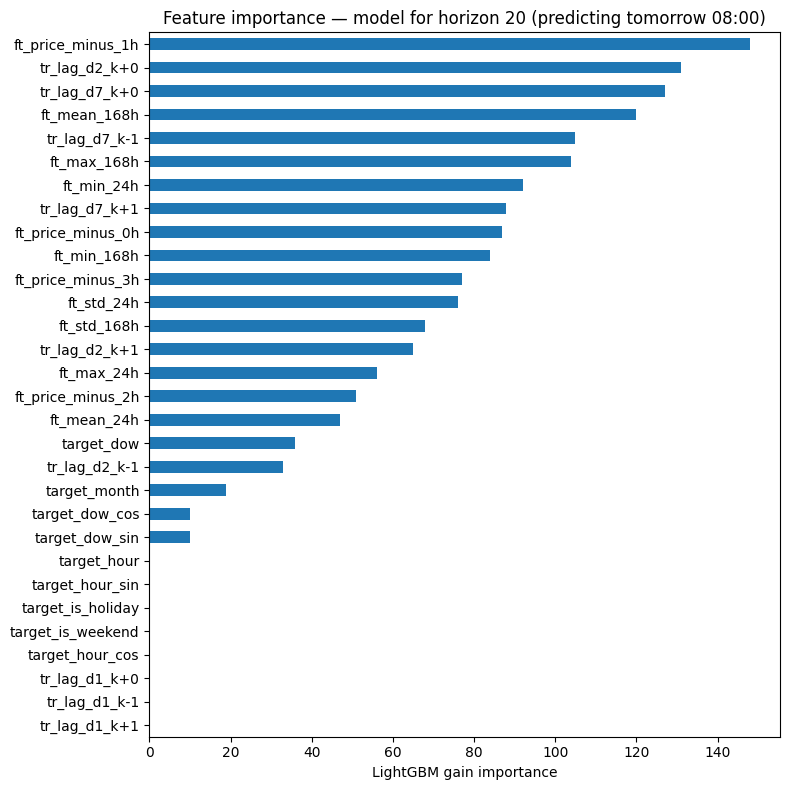

In [21]:
model_h20 = result.models[20]
importances = pd.Series(
    model_h20.feature_importances_,
    index=result.feature_names,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot.barh(ax=ax)
ax.set_title("Feature importance — model for horizon 20 (predicting tomorrow 08:00)")
ax.set_xlabel("LightGBM gain importance")
plt.tight_layout()
plt.show()

In [26]:
# Pick a forecast time and verify all 9 tr_* lag values for 3 horizons
t = pd.Timestamp("2024-03-14 12:00", tz="Europe/Athens")
gate_closure = 12

mask = meta["forecast_time"] == t
rows = X[mask].reset_index(drop=True)
day_meta = meta[mask].reset_index(drop=True)

for h in [0, 12, 18]:
    distance = (24 - gate_closure) + h
    target_time = t + pd.Timedelta(hours=distance)
    print("=" * 80)
    print(f"horizon={h}  →  target={target_time}  (distance={distance}h)")

    idx = day_meta[day_meta["horizon"] == h].index[0]
    row = rows.iloc[idx]

    for d in (1, 2, 7):
        for k in (-1, 0, 1):
            col = f"tr_lag_d{d}_k{k:+d}"
            offset = 24 * d - k
            ftime = target_time - pd.Timedelta(hours=offset)
            legal = ftime <= t
            actual = row[col]

            if legal:
                expected = prices.loc[ftime]
                ok = pd.notna(actual) and abs(actual - expected) < 1e-6
                line = f"  {col:<14} ftime={ftime}  expected={expected:.2f}  actual={actual:.2f}  {'✓' if ok else '✗'}"
            else:
                ok = pd.isna(actual)
                actstr = "NaN" if pd.isna(actual) else f"{actual:.2f}"
                line = f"  {col:<14} ftime={ftime}  expected=NaN(leak)  actual={actstr}  {'✓' if ok else '✗'}"
            print(line)
    print()

horizon=0  →  target=2024-03-15 00:00:00+02:00  (distance=12h)
  tr_lag_d1_k-1  ftime=2024-03-13 23:00:00+02:00  expected=79.07  actual=79.07  ✓
  tr_lag_d1_k+0  ftime=2024-03-14 00:00:00+02:00  expected=65.77  actual=65.77  ✓
  tr_lag_d1_k+1  ftime=2024-03-14 01:00:00+02:00  expected=55.47  actual=55.47  ✓
  tr_lag_d2_k-1  ftime=2024-03-12 23:00:00+02:00  expected=79.79  actual=79.79  ✓
  tr_lag_d2_k+0  ftime=2024-03-13 00:00:00+02:00  expected=71.61  actual=71.61  ✓
  tr_lag_d2_k+1  ftime=2024-03-13 01:00:00+02:00  expected=60.30  actual=60.30  ✓
  tr_lag_d7_k-1  ftime=2024-03-07 23:00:00+02:00  expected=85.58  actual=85.58  ✓
  tr_lag_d7_k+0  ftime=2024-03-08 00:00:00+02:00  expected=69.28  actual=69.28  ✓
  tr_lag_d7_k+1  ftime=2024-03-08 01:00:00+02:00  expected=56.93  actual=56.93  ✓

horizon=12  →  target=2024-03-15 12:00:00+02:00  (distance=24h)
  tr_lag_d1_k-1  ftime=2024-03-14 11:00:00+02:00  expected=127.52  actual=127.52  ✓
  tr_lag_d1_k+0  ftime=2024-03-14 12:00:00+02:00  

In [28]:
t = pd.Timestamp("2024-03-14 12:00", tz="Europe/Athens")
gate_closure_hour = 12
h = 12
d = 1
k = 0

col_name = f"tr_lag_d{d}_k{k:+d}"

distance_hours = (24 - gate_closure_hour) + h
target_time = t + pd.Timedelta(hours=distance_hours)

offset_hours = 24 * d - k
feature_time = target_time - pd.Timedelta(hours=offset_hours)

is_legal = feature_time <= t

print(f"Forecast time t          = {t}")
print(f"Distance t -> target     = {distance_hours}h")
print(f"Target time              = {target_time}")
print(f"Offset target -> feature = {offset_hours}h")
print(f"Feature time             = {feature_time}")
print(f"Leakage-safe (ftime<=t)? = {is_legal}")
print()

if not is_legal:
    print(f"This lag should be NaN (would leak).")

true_target_value = prices.loc[target_time]
print(f"Price at target time   = {true_target_value:.2f}  (y, what we predict)")

if is_legal:
    true_feature_value = prices.loc[feature_time]
    print(f"Price at feature time  = {true_feature_value:.2f}  (X[{col_name}])")

mask = meta["forecast_time"] == t
rows_of_t = X[mask]
row_of_horizon = rows_of_t.loc[rows_of_t["horizon"] == h]
pipeline_feature_value = row_of_horizon[col_name].values[0]

print()
print(f"Pipeline value for {col_name}: ", end="")
if pd.isna(pipeline_feature_value):
    print("NaN")
else:
    print(f"{pipeline_feature_value:.2f}")

if is_legal:
    match = pd.notna(pipeline_feature_value) and abs(pipeline_feature_value - true_feature_value) < 1e-6
    print(f"Match (pipeline == manual lookup): {match}")
else:
    match = pd.isna(pipeline_feature_value)
    print(f"Match (pipeline correctly NaN): {match}")

Forecast time t          = 2024-03-14 12:00:00+02:00
Distance t -> target     = 24h
Target time              = 2024-03-15 12:00:00+02:00
Offset target -> feature = 24h
Feature time             = 2024-03-14 12:00:00+02:00
Leakage-safe (ftime<=t)? = True

Price at target time   = 131.39  (y, what we predict)
Price at feature time  = 120.56  (X[tr_lag_d1_k+0])

Pipeline value for tr_lag_d1_k+0: 120.56
Match (pipeline == manual lookup): True
